<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/%D0%A1%D3%A8%D0%96_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Recurrent Neural Networks (RNN)

Дәстүрлі нейрондық желілерден айырмашылығы, RNN-нің **жады** бар. Ол ақпаратты тізбек бойынша сақтайды. Бұл оны мәтін, аудио немесе уақыттық қатарлар (time series) сияқты деректермен жұмыс істеуге таптырмас құрал етеді.

**Негізгі формула:**


Жасырын күй (hidden state)  келесі формула бойынша есептеледі:


$$h_t = \phi(W_{hh}h_{t-1} + W_{xh}x_t + b_h)$$


Мұнда:

$h_t$ — ағымдағы уақыттағы жады.

$x_t$ — кіріс дерегі.

$\phi$ — активация функциясы (әдетте $tanh$).




In [1]:
# Қажетті кітапханаларды импорттау
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# 1. URL анықтау
url = 'https://raw.githubusercontent.com/mwitiderrick/stockprice/master/NSE-TATAGLOBAL.csv'

# 2. Деректерді оқу
df = pd.read_csv(url)

# Алғашқы жолдар
print(df.head())

         Date    Open    High     Low    Last   Close  Total Trade Quantity  \
0  2018-09-28  234.05  235.95  230.20  233.50  233.75               3069914   
1  2018-09-27  234.55  236.80  231.10  233.80  233.25               5082859   
2  2018-09-26  240.00  240.00  232.50  235.00  234.25               2240909   
3  2018-09-25  233.30  236.75  232.00  236.25  236.10               2349368   
4  2018-09-24  233.55  239.20  230.75  234.00  233.30               3423509   

   Turnover (Lacs)  
0          7162.35  
1         11859.95  
2          5248.60  
3          5503.90  
4          7999.55  


## 3. Деректерді алдын ала өңдеу

In [2]:
## 3. Деректерді алдын ала өңдеу

# "Open" бағанасын қолданамыз
data = df.iloc[:, 1:2].values

# Нормализация
scaler = MinMaxScaler(feature_range=(0, 1))

# 3. TODO
scaled_data = scaler.fit_transform(data)

# Train/Test бөлу
train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

def create_sequences(data, seq_length):

    x = []
    y = []

    for i in range(len(data) - seq_length):

        # 4. Терезе алу
        _x = data[i:i + seq_length]

        # 5. Келесі мән
        _y = data[i + seq_length]

        x.append(_x)
        y.append(_y)

    return np.array(x), np.array(y)

seq_length = 60

# 6. Sequence жасау
X_train, y_train = create_sequences(train_data, seq_length)

X_test, y_test = create_sequences(test_data, seq_length)

# Tensor-ға айналдыру
X_train = torch.from_numpy(X_train).float()

y_train = torch.from_numpy(y_train).float()


## 4. RNN Моделін құру

In [3]:
## 4. RNN Моделін құру

class SimpleRNN(nn.Module):

    def __init__(self, input_size, hidden_size, output_size):

        super(SimpleRNN, self).__init__()

        # 7. Hidden size
        self.hidden_size = hidden_size

        # 8. RNN қабаты
        self.rnn = nn.RNN(
            input_size,
            hidden_size,
            batch_first=True
        )

        # 9. Linear қабаты
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        # 10. h0
        h0 = torch.zeros(
            1,
            x.size(0),
            self.hidden_size
        )

        # 11. RNN forward
        out, _ = self.rnn(x, h0)

        # Соңғы timestep
        out = self.fc(out[:, -1, :])

        return out


# Параметрлер
input_size = 1
hidden_size = 64
output_size = 1

# 12. Модель
model = SimpleRNN(
    input_size,
    hidden_size,
    output_size
)

print(model)

SimpleRNN(
  (rnn): RNN(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## 5. Модельді жаттықтыру

In [4]:
## 5. Модельді жаттықтыру

# 13. Loss функциясы
criterion = nn.MSELoss()

# 14. Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 20

for epoch in range(epochs):

    # 15. Gradient reset
    optimizer.zero_grad()

    # 16. Forward pass
    outputs = model(X_train)

    # 17. Loss
    loss = criterion(outputs, y_train)

    # 18. Backward
    loss.backward()

    # 19. Weight update
    optimizer.step()

    if (epoch + 1) % 5 == 0:

        print(
            f'Epoch [{epoch+1}/{epochs}], '
            f'Loss: {loss.item():.4f}'
        )

Epoch [5/20], Loss: 0.0339
Epoch [10/20], Loss: 0.0264
Epoch [15/20], Loss: 0.0225
Epoch [20/20], Loss: 0.0158


## 6. Болжам жасау және нәтижені визуализациялау

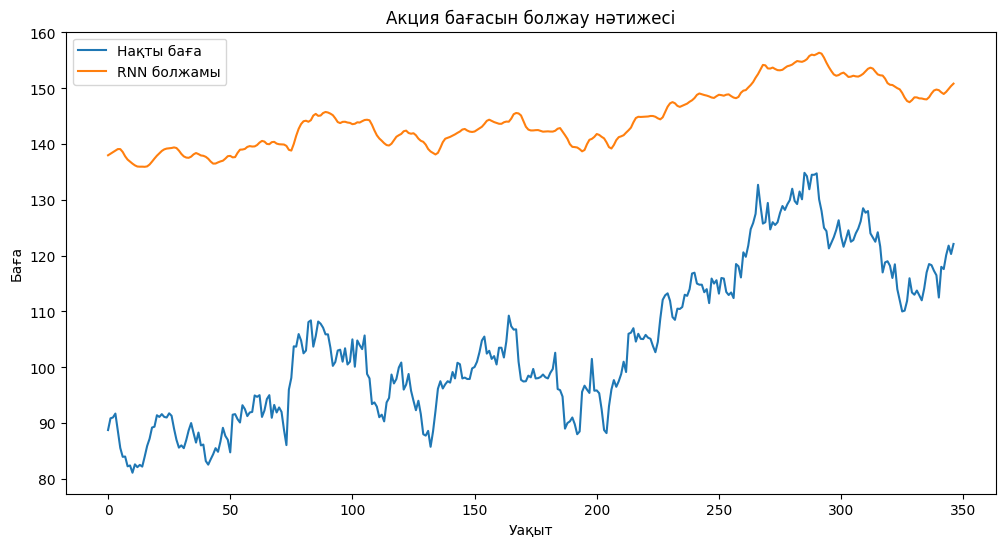

In [5]:
## 6. Болжам жасау

model.eval()

with torch.no_grad():

    # Tensor
    X_test_tensor = torch.from_numpy(X_test).float()

    # 20. Prediction
    predictions = model(X_test_tensor)

    # Inverse transform
    predictions = scaler.inverse_transform(
        predictions.numpy()
    )

    actual = scaler.inverse_transform(y_test)

# Visualization
plt.figure(figsize=(12,6))

plt.plot(actual, label='Нақты баға')

plt.plot(predictions, label='RNN болжамы')

plt.title('Акция бағасын болжау нәтижесі')

plt.xlabel('Уақыт')

plt.ylabel('Баға')

plt.legend()

plt.show()